# Feature Engineering - Supply Chain Optimization

Code for feature engineering

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Use default colors
plt.style.use('default')
sns.set_palette('husl')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## Load Data

In [2]:
# Load all CSV files
customer = pd.read_csv('data/dim_customer.csv')
date = pd.read_csv('data/dim_date.csv')
facility = pd.read_csv('data/dim_facility.csv')
product = pd.read_csv('data/dim_product.csv')
supplier = pd.read_csv('data/dim_supplier.csv')

inventory = pd.read_csv('data/fact_inventory.csv')
procurement = pd.read_csv('data/fact_procurement.csv')
production = pd.read_csv('data/fact_production.csv')
sales = pd.read_csv('data/fact_sales.csv')
shipment = pd.read_csv('data/fact_shipment.csv')

# Show data shapes
print('Dimension Tables:')
print(f'Customer: {customer.shape}')
print(f'Date: {date.shape}')
print(f'Facility: {facility.shape}')
print(f'Product: {product.shape}')
print(f'Supplier: {supplier.shape}')
print()
print('Fact Tables:')
print(f'Inventory: {inventory.shape}')
print(f'Procurement: {procurement.shape}')
print(f'Production: {production.shape}')
print(f'Sales: {sales.shape}')
print(f'Shipment: {shipment.shape}')

Dimension Tables:
Customer: (5, 7)
Date: (2192, 11)
Facility: (5, 8)
Product: (20, 10)
Supplier: (10, 8)

Fact Tables:
Inventory: (8000, 7)
Procurement: (3000, 11)
Production: (9000, 8)
Sales: (100000, 14)
Shipment: (12000, 13)


## Join Tables

In [3]:
# Merge sales with dimensions
sales_merged = sales.merge(customer, on='customer_id', how='left')
sales_merged = sales_merged.merge(product, on='product_id', how='left')
sales_merged = sales_merged.merge(date, left_on='date_key', right_on='date_key', how='left')

print('Sales merged shape:', sales_merged.shape)
print(sales_merged.head())

Sales merged shape: (100000, 39)
   sales_id  date_key  product_id  customer_id  quantity_sold  unit_price_x  \
0         1      1093           7            4             49           800   
1         2      1276          20            2              1            70   
2         3      1314          15            2             49           220   
3         4       515          11            5             37            95   
4         5       792           8            5             50           250   

   discount_pct order_number  discount_amount  gross_revenue  net_revenue  \
0        5.0000  ORD-0000001        1960.0000          39200   37240.0000   
1       15.0000  ORD-0000002          10.5000             70      59.5000   
2       15.0000  ORD-0000003        1617.0000          10780    9163.0000   
3        0.0000  ORD-0000004           0.0000           3515    3515.0000   
4       15.0000  ORD-0000005        1875.0000          12500   10625.0000   

   total_cost     profit  pro

## Inventory Features

In [4]:
# Make a copy to work with
inv = inventory.copy()

# Feature 1: Stock coverage ratio
inv['stock_coverage'] = inv['stock_level'] / (inv['safety_stock_level'] + 1)

# Feature 2: Reorder gap
inv['reorder_gap'] = inv['stock_level'] - inv['reorder_point']

# Feature 3: Stockout risk (1 if below reorder point, 0 otherwise)
inv['stockout_risk'] = (inv['stock_level'] < inv['reorder_point']).astype(int)

# Feature 4: Overstocked (1 if very high, 0 otherwise)
inv['is_overstocked'] = (inv['stock_level'] > inv['safety_stock_level'] * 2).astype(int)

print('Inventory features created')
print(inv[['stock_level', 'stock_coverage', 'reorder_gap', 'stockout_risk']].head())

Inventory features created
   stock_level  stock_coverage  reorder_gap  stockout_risk
0         1887          4.2215         1627              0
1          842          2.0338          283              0
2         1956          4.3857         1845              0
3         1702         14.5470         1533              0
4         1269         22.6607          672              0


## Procurement Features

In [5]:
# Make a copy to work with
proc = procurement.copy()

# Feature 1: Cost per unit
proc['cost_per_unit'] = proc['total_cost'] / (proc['order_quantity'] + 1)

# Feature 2: Is urgent (lead time < 5 days)
proc['is_urgent'] = (proc['lead_time_days'] < 5).astype(int)

# Feature 3: Good quality (score > median)
quality_median = proc['quality_score'].median()
proc['good_quality'] = (proc['quality_score'] > quality_median).astype(int)

# Feature 4: Lead time category (Fast, Medium, Slow)
proc['lead_time_category'] = pd.cut(proc['lead_time_days'], 
                                      bins=3, 
                                      labels=['Fast', 'Medium', 'Slow'])

print('Procurement features created')
print(proc[['cost_per_unit', 'is_urgent', 'good_quality', 'lead_time_category']].head())

Procurement features created
   cost_per_unit  is_urgent  good_quality lead_time_category
0         8.9323          0             1             Medium
1        35.4590          0             1               Fast
2        30.9756          0             0               Fast
3        11.0587          0             0               Slow
4        54.4224          0             0               Fast


## Production Features

In [6]:
# Make a copy to work with
prod = production.copy()

# Feature 1: Production efficiency
prod['efficiency'] = 100 - prod['defect_rate_pct']

# Feature 2: Good batch (defect rate < 5%)
prod['good_batch'] = (prod['defect_rate_pct'] < 5).astype(int)

# Feature 3: Has defects
prod['has_defects'] = (prod['defective_units'] > 0).astype(int)

# Feature 4: Waste cost
# Assume defective units lose 50% of value
prod['waste_cost'] = prod['defective_units'] * 0.5

print('Production features created')
print(prod[['efficiency', 'good_batch', 'has_defects', 'waste_cost']].head())

Production features created
   efficiency  good_batch  has_defects  waste_cost
0     99.1500           1            1      0.5000
1     97.1700           1            1      7.5000
2     96.9200           1            1     10.0000
3     96.4500           1            1     15.0000
4     95.5100           1            1     18.5000


## Sales Features

In [7]:
# Make a copy to work with
sal = sales.copy()

# Feature 1: Discount impact
sal['discount_impact'] = sal['gross_revenue'] - sal['net_revenue']

# Feature 2: Revenue per unit
sal['revenue_per_unit'] = sal['gross_revenue'] / (sal['quantity_sold'] + 1)

# Feature 3: High discount flag
sal['high_discount'] = (sal['discount_pct'] > 10).astype(int)

# Feature 4: High profit flag
profit_median = sal['profit'].median()
sal['high_profit'] = (sal['profit'] > profit_median).astype(int)

# Feature 5: Bulk order flag
qty_q75 = sal['quantity_sold'].quantile(0.75)
sal['is_bulk'] = (sal['quantity_sold'] > qty_q75).astype(int)

print('Sales features created')
print(sal[['discount_impact', 'revenue_per_unit', 'high_discount', 'high_profit']].head())

Sales features created
   discount_impact  revenue_per_unit  high_discount  high_profit
0        1960.0000          784.0000              0            1
1          10.5000           35.0000              1            0
2        1617.0000          215.6000              1            1
3           0.0000           92.5000              0            1
4        1875.0000          245.0980              1            1


## Shipment Features

In [8]:
# Make a copy to work with
ship = shipment.copy()

# Feature 1: Shipping cost per unit
ship['cost_per_unit'] = ship['shipping_cost'] / (ship['quantity'] + 1)

# Feature 2: Cost per kg
ship['cost_per_kg'] = ship['shipping_cost'] / (ship['total_weight_kg'] + 1)

# Feature 3: On time delivery
ship['on_time'] = (ship['status'] == 'Delivered').astype(int)

# Feature 4: Is delayed
ship['is_delayed'] = (ship['status'] == 'Delayed').astype(int)

print('Shipment features created')
print(ship[['cost_per_unit', 'cost_per_kg', 'on_time', 'is_delayed']].head())

Shipment features created
   cost_per_unit  cost_per_kg  on_time  is_delayed
0        16.1657      70.7250        0           1
1         0.0673       0.0450        1           0
2        21.8676       9.7706        0           0
3         4.7187       0.7318        0           1
4         2.1440       0.3317        0           0


## Categorical Encoding

In [9]:
# Encode categorical columns in sales data
le_channel = LabelEncoder()
le_category = LabelEncoder()

sales_merged['channel_encoded'] = le_channel.fit_transform(sales_merged['channel_type'])
sales_merged['category_encoded'] = le_category.fit_transform(sales_merged['category'])

print('Categorical variables encoded')
print('Channel types:', sales_merged['channel_type'].unique())
print('Channel encoded:', sales_merged['channel_encoded'].unique())

Categorical variables encoded
Channel types: ['Online' 'Retail' 'Wholesale']
Channel encoded: [0 1 2]


## Supplier Aggregated Features

In [10]:
# Group procurement by supplier
supplier_agg = proc.groupby('supplier_id').agg({
    'quality_score': 'mean',
    'lead_time_days': 'mean',
    'cost_per_unit': 'mean',
    'is_urgent': 'sum',
    'good_quality': 'mean'
}).reset_index()

supplier_agg.columns = ['supplier_id', 'avg_quality', 'avg_lead_time', 
                         'avg_cost', 'urgent_orders', 'reliability']

# Reliability index (0-100)
supplier_agg['reliability_index'] = supplier_agg['reliability'] * 100

print('Supplier aggregated features')
print(supplier_agg)

Supplier aggregated features
   supplier_id  avg_quality  avg_lead_time  avg_cost  urgent_orders  \
0            1       4.0249        32.3230  107.0943              0   
1            2       4.0210        33.7760  108.4323              0   
2            3       4.0119        31.6678  102.6847              0   
3            4       4.0400        32.5515  139.2231              0   
4            5       4.0301        33.4440  114.6391              0   
5            6       3.9549        32.1182  112.0004              0   
6            7       4.0211        33.5016  113.1104              0   
7            8       3.9400        32.3135   92.0426              0   
8            9       4.0214        33.2332   98.6546              0   
9           10       3.9879        33.3247  105.1186              0   

   reliability  reliability_index  
0       0.5342            53.4161  
1       0.5260            52.5974  
2       0.4832            48.3221  
3       0.5368            53.6765  
4       0

## Customer Aggregated Features

In [11]:
# Group sales by customer
customer_agg = sales_merged.groupby('customer_id').agg({
    'quantity_sold': 'sum',
    'profit': 'sum',
    'net_revenue': 'sum',
    'discount_pct': 'mean',
    'profit_margin_pct': 'mean'
}).reset_index()

customer_agg.columns = ['customer_id', 'total_quantity', 'total_profit', 
                         'total_revenue', 'avg_discount', 'avg_margin']

print('Customer aggregated features')
print(customer_agg)

Customer aggregated features
   customer_id  total_quantity  total_profit  total_revenue  avg_discount  \
0            1          508401 47993927.5000 104276056.5000        7.0613   
1            2          519935 50497151.2500 109489085.2500        7.1619   
2            3          507537 48421878.2500 105116196.2500        7.1906   
3            4          509279 48012281.7500 103878568.7500        7.1314   
4            5          512449 48292538.0000 104641449.0000        7.0845   

   avg_margin  
0     50.5639  
1     50.5359  
2     50.5240  
3     50.5587  
4     50.6009  


## Product Aggregated Features

In [12]:
# Group sales by product
product_agg = sales_merged.groupby('product_id').agg({
    'quantity_sold': 'sum',
    'profit': 'sum',
    'net_revenue': 'sum',
    'profit_margin_pct': 'mean'
}).reset_index()

product_agg.columns = ['product_id', 'total_sold', 'total_profit', 
                        'total_revenue', 'avg_margin']

# Product value category
product_agg['value_category'] = pd.cut(product_agg['total_revenue'], 
                                         bins=3, 
                                         labels=['Low', 'Medium', 'High'])

print('Product aggregated features')
print(product_agg)

Product aggregated features
    product_id  total_sold  total_profit  total_revenue  avg_margin  \
0            1      126460 49692180.0000 140743380.0000     34.8363   
1            2      128414  2258005.0000   4184215.0000     53.6250   
2            3      126648  7143900.0000  14109540.0000     50.2830   
3            4      130292 19535075.0000  42336175.0000     45.7774   
4            5      128182  5597799.5000  10725079.5000     51.8907   
5            6      127418 27735672.5000  53219272.5000     51.7938   
6            7      128488 46563080.0000  95388520.0000     48.5173   
7            8      127188 15459107.5000  29449787.5000     52.2262   
8            9      129000 11250192.0000  21570192.0000     51.8842   
9           10      127290  1680883.7500   2953783.7500     56.6355   
10          11      125635  5832226.2500  11108896.2500     52.1754   
11          12      127838  6020987.5000  13052077.5000     45.7514   
12          13      129622  3514902.7500   662583

## Visualization - Feature Distributions

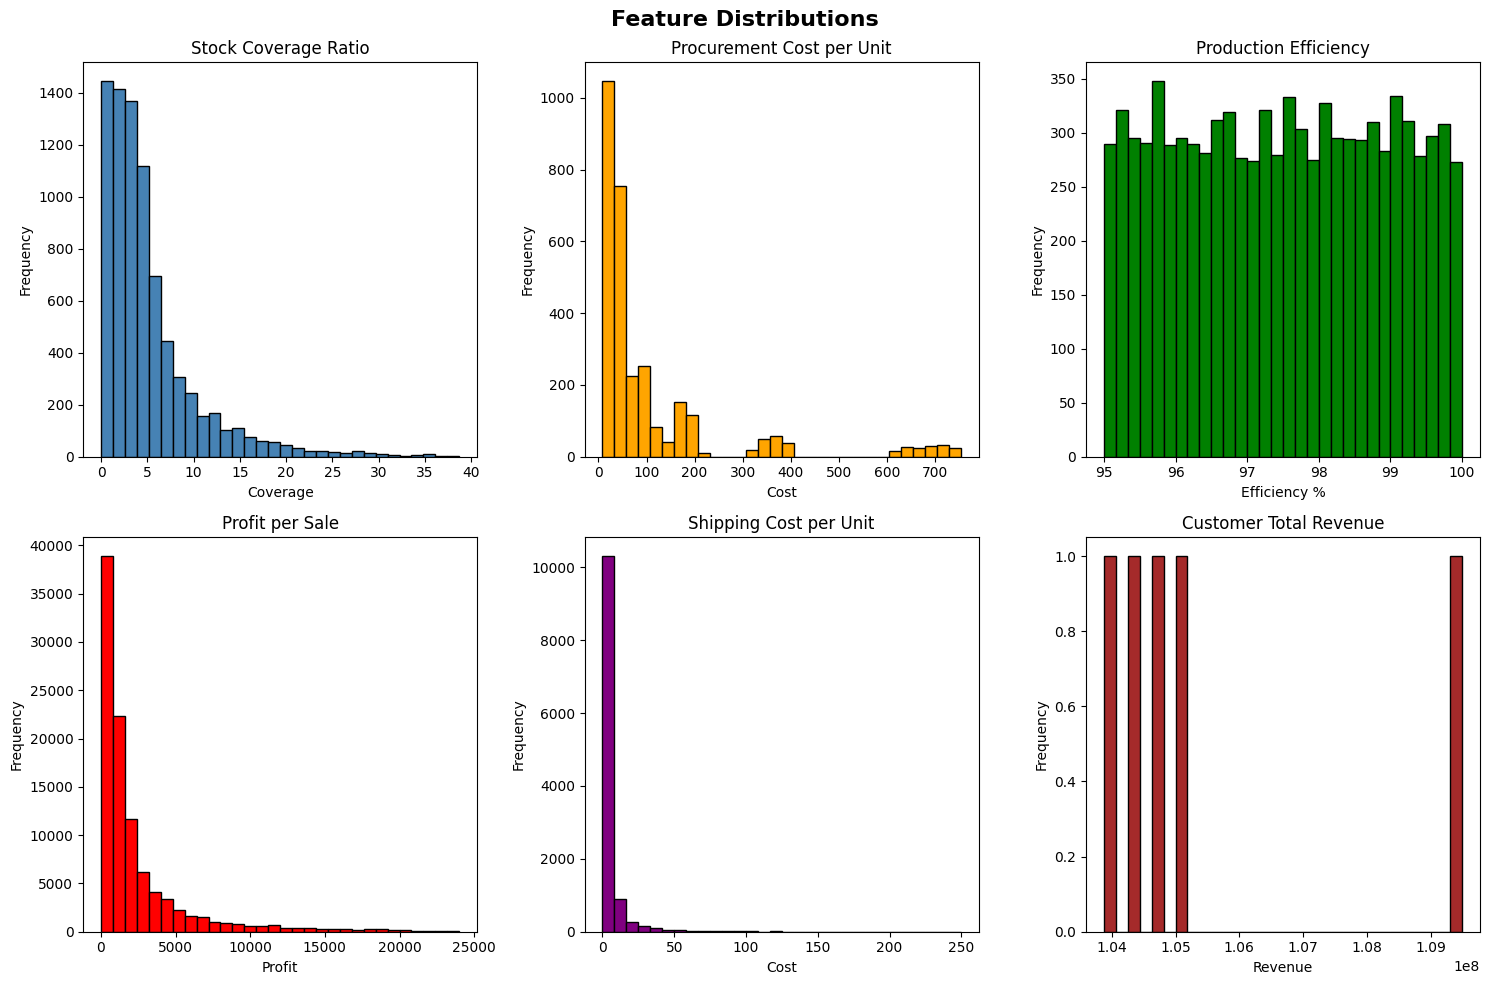

Visualization complete


In [13]:
# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold')

# Plot 1: Stock coverage
axes[0, 0].hist(inv['stock_coverage'], bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Stock Coverage Ratio')
axes[0, 0].set_xlabel('Coverage')
axes[0, 0].set_ylabel('Frequency')

# Plot 2: Cost per unit
axes[0, 1].hist(proc['cost_per_unit'], bins=30, color='orange', edgecolor='black')
axes[0, 1].set_title('Procurement Cost per Unit')
axes[0, 1].set_xlabel('Cost')
axes[0, 1].set_ylabel('Frequency')

# Plot 3: Production efficiency
axes[0, 2].hist(prod['efficiency'], bins=30, color='green', edgecolor='black')
axes[0, 2].set_title('Production Efficiency')
axes[0, 2].set_xlabel('Efficiency %')
axes[0, 2].set_ylabel('Frequency')

# Plot 4: Profit per sale
axes[1, 0].hist(sal['profit'], bins=30, color='red', edgecolor='black')
axes[1, 0].set_title('Profit per Sale')
axes[1, 0].set_xlabel('Profit')
axes[1, 0].set_ylabel('Frequency')

# Plot 5: Shipping cost
axes[1, 1].hist(ship['cost_per_unit'], bins=30, color='purple', edgecolor='black')
axes[1, 1].set_title('Shipping Cost per Unit')
axes[1, 1].set_xlabel('Cost')
axes[1, 1].set_ylabel('Frequency')

# Plot 6: Customer revenue
axes[1, 2].hist(customer_agg['total_revenue'], bins=30, color='brown', edgecolor='black')
axes[1, 2].set_title('Customer Total Revenue')
axes[1, 2].set_xlabel('Revenue')
axes[1, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print('Visualization complete')

## Correlation Analysis


Top Features Correlated with Profit:
profit            1.0000
net_revenue       0.9730
gross_revenue     0.9555
total_cost        0.9234
unit_price_x      0.7612
unit_price_y      0.7612
unit_cost         0.7339
weight_kg         0.4600
discount_amount   0.4256
quantity_sold     0.3905
Name: profit, dtype: float64


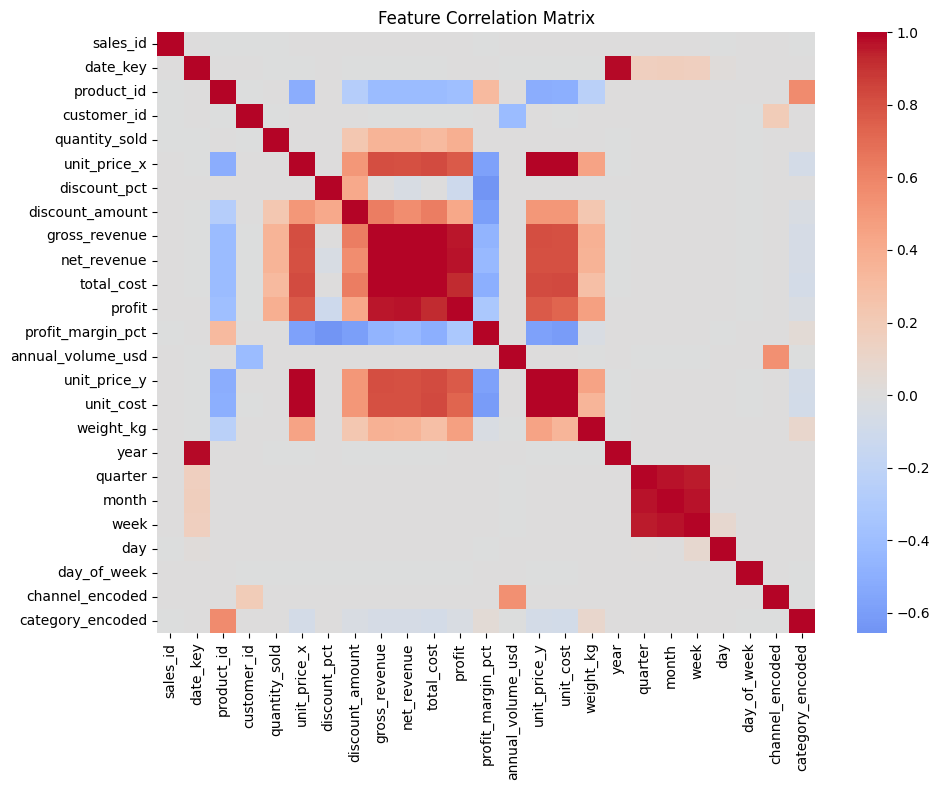

In [14]:
# Select numeric columns from sales
numeric_cols = sales_merged.select_dtypes(include=[np.number]).columns
corr_matrix = sales_merged[numeric_cols].corr()

# Show correlation with profit
profit_corr = corr_matrix['profit'].sort_values(ascending=False)
print('\nTop Features Correlated with Profit:')
print(profit_corr.head(10))

# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Export Features

In [15]:
# Create output directory
import os
os.makedirs('engineered_features', exist_ok=True)

# Save all engineered datasets
inv.to_csv('engineered_features/inventory_features.csv', index=False)
proc.to_csv('engineered_features/procurement_features.csv', index=False)
prod.to_csv('engineered_features/production_features.csv', index=False)
sal.to_csv('engineered_features/sales_features.csv', index=False)
ship.to_csv('engineered_features/shipment_features.csv', index=False)

supplier_agg.to_csv('engineered_features/supplier_profile.csv', index=False)
customer_agg.to_csv('engineered_features/customer_profile.csv', index=False)
product_agg.to_csv('engineered_features/product_profile.csv', index=False)

# Save merged sales data with all features
sales_merged.to_csv('engineered_features/sales_with_features.csv', index=False)

print('All engineered features exported!')
print('\nFiles saved:')
for file in os.listdir('engineered_features'):
    path = f'engineered_features/{file}'
    size = os.path.getsize(path) / 1024
    print(f'  {file:40s} - {size:>8.1f} KB')

All engineered features exported!

Files saved:
  customer_profile.csv                     -      0.4 KB
  inventory_features.csv                   -    418.5 KB
  procurement_features.csv                 -    244.8 KB
  production_features.csv                  -    470.7 KB
  product_profile.csv                      -      1.1 KB
  sales_features.csv                       -   9584.6 KB
  sales_with_features.csv                  -  24320.5 KB
  shipment_features.csv                    -   1287.4 KB
  supplier_profile.csv                     -      1.0 KB


## Summary

In [16]:
print('='*70)
print('FEATURE ENGINEERING SUMMARY')
print('='*70)
print()
print('INVENTORY FEATURES:')
print('  - stock_coverage: Current stock / safety stock')
print('  - reorder_gap: Stock level - reorder point')
print('  - stockout_risk: Flag if stock < reorder point')
print('  - is_overstocked: Flag if stock > 2x safety stock')
print()
print('PROCUREMENT FEATURES:')
print('  - cost_per_unit: Total cost / order quantity')
print('  - is_urgent: Flag if lead time < 5 days')
print('  - good_quality: Flag if quality > median')
print('  - lead_time_category: Fast / Medium / Slow')
print()
print('PRODUCTION FEATURES:')
print('  - efficiency: 100 - defect_rate')
print('  - good_batch: Flag if defect rate < 5%')
print('  - has_defects: Flag if defective units > 0')
print('  - waste_cost: Defective units * 0.5')
print()
print('SALES FEATURES:')
print('  - discount_impact: Gross revenue - net revenue')
print('  - revenue_per_unit: Gross revenue / quantity')
print('  - high_discount: Flag if discount > 10%')
print('  - high_profit: Flag if profit > median')
print('  - is_bulk: Flag if quantity > 75th percentile')
print()
print('SHIPMENT FEATURES:')
print('  - cost_per_unit: Shipping cost / quantity')
print('  - cost_per_kg: Shipping cost / weight')
print('  - on_time: Flag if status = Delivered')
print('  - is_delayed: Flag if status = Delayed')
print()
print('AGGREGATED FEATURES:')
print('  - Supplier: avg quality, lead time, cost, reliability')
print('  - Customer: total quantity, profit, revenue, discounts')
print('  - Product: total sold, profit, revenue, margin, value category')
print()
print('='*70)

FEATURE ENGINEERING SUMMARY

INVENTORY FEATURES:
  - stock_coverage: Current stock / safety stock
  - reorder_gap: Stock level - reorder point
  - stockout_risk: Flag if stock < reorder point
  - is_overstocked: Flag if stock > 2x safety stock

PROCUREMENT FEATURES:
  - cost_per_unit: Total cost / order quantity
  - is_urgent: Flag if lead time < 5 days
  - good_quality: Flag if quality > median
  - lead_time_category: Fast / Medium / Slow

PRODUCTION FEATURES:
  - efficiency: 100 - defect_rate
  - good_batch: Flag if defect rate < 5%
  - has_defects: Flag if defective units > 0
  - waste_cost: Defective units * 0.5

SALES FEATURES:
  - discount_impact: Gross revenue - net revenue
  - revenue_per_unit: Gross revenue / quantity
  - high_discount: Flag if discount > 10%
  - high_profit: Flag if profit > median
  - is_bulk: Flag if quantity > 75th percentile

SHIPMENT FEATURES:
  - cost_per_unit: Shipping cost / quantity
  - cost_per_kg: Shipping cost / weight
  - on_time: Flag if status 